                 timestamp                 event_type  \
0  2025-12-03 00:06:00.000    claude_code.user_prompt   
1  2025-12-03 00:06:00.275    claude_code.api_request   
2  2025-12-03 00:06:09.353  claude_code.tool_decision   
3  2025-12-03 00:06:09.773    claude_code.api_request   
4  2025-12-03 00:08:07.213    claude_code.user_prompt   

       attr.event.timestamp                  attr.organization.id  \
0  2025-12-03T00:06:00.000Z  9e0ffda6-f44a-43ed-ae1c-7c4e7fe06845   
1  2025-12-03T00:06:00.275Z  9e0ffda6-f44a-43ed-ae1c-7c4e7fe06845   
2  2025-12-03T00:06:09.353Z  9e0ffda6-f44a-43ed-ae1c-7c4e7fe06845   
3  2025-12-03T00:06:09.773Z  9e0ffda6-f44a-43ed-ae1c-7c4e7fe06845   
4  2025-12-03T00:08:07.213Z  9e0ffda6-f44a-43ed-ae1c-7c4e7fe06845   

                        attr.session.id attr.terminal.type  \
0  8ba51b14-d085-47c8-a2d3-b69d72c16fac             vscode   
1  8ba51b14-d085-47c8-a2d3-b69d72c16fac             vscode   
2  8ba51b14-d085-47c8-a2d3-b69d72c16fac             vsco

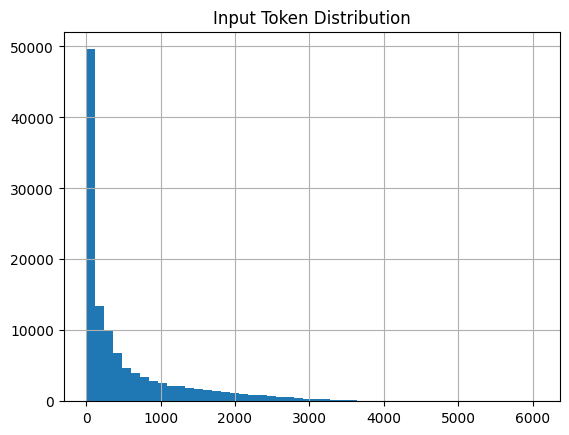

Model usage:
attr.model
claude-haiku-4-5-20251001     46528
claude-opus-4-6               26249
claude-opus-4-5-20251101      23986
claude-sonnet-4-5-20250929    19906
claude-sonnet-4-6              2707
Name: count, dtype: int64

Cost distribution:
count    118014.000000
mean          0.050854
std           0.065586
min           0.000000
25%           0.001301
50%           0.010905
75%           0.090421
max           0.437199
Name: attr.cost_usd, dtype: float64



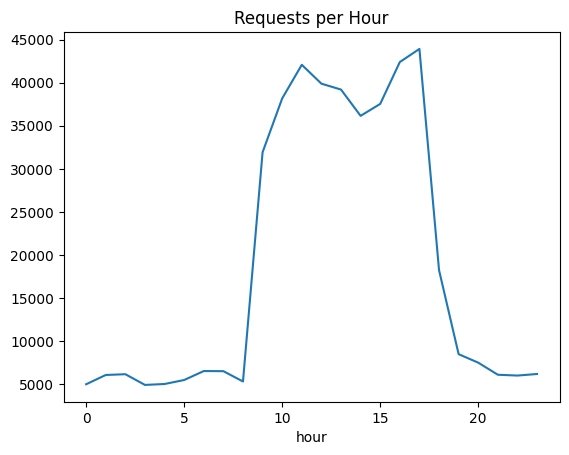

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/processed_events.csv")

print(df.head())
print()

print(df.shape)
print()
print("Missing values:")
print(df.isnull().sum().sort_values(ascending=False))
print()
print("Event type distribution:")
print(df["event_type"].value_counts())
print()

df["attr.input_tokens"].hist(bins=50)
plt.title("Input Token Distribution")
plt.show()

print("Model usage:")
print(df["attr.model"].value_counts())
print()
print("Cost distribution:")
print(df["attr.cost_usd"].describe())
print()

df.groupby("hour").size().plot()
plt.title("Requests per Hour")
plt.show()

### Missing Values Explanation

The telemetry dataset contains multiple event types such as:

- API requests
- Tool executions
- Error events

Each event type contains a different set of attributes.  
When the JSON logs are normalized into a tabular format, columns that are not relevant for a specific event type naturally contain missing values.

For example:
- `attr.input_tokens` exists only for API requests
- `attr.tool_name` exists only for tool execution events
- `attr.error` exists only for error events

Therefore, the presence of missing values in these columns is expected and reflects the heterogeneous nature of telemetry events rather than data quality issues.